# ML - BOOSTING

In [ ]:
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from utils1 import get_classifier_metrics
from sklearn.model_selection import GridSearchCV
from collections import Counter
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

## Paso 1. Lectura del conjunto de datos procesado

In [8]:
# Cargamos los dataframes, el dataframe de los datos invalidos imputados con la moda no lo cargamos ya que en modelos anteriores es el que peor metricas tiene y para predicciones de salud no es recomendable.
with open('../data/processed/04_df_invalids_removed.pkl', 'rb') as f:
    df_invalids_removed = pickle.load(f)

with open('../data/processed/04_df_invalids_knn.pkl', 'rb') as f:
    df_invalids_knn = pickle.load(f)

## Paso 2. Split

In [9]:
X_invalids_removed = df_invalids_removed.drop('Outcome', axis= 1)
y_invalids_removed = df_invalids_removed['Outcome']

X_invalids_knn= df_invalids_knn.drop('Outcome', axis= 1)
y_invalids_knn = df_invalids_knn['Outcome']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_invalids_removed, y_invalids_removed, test_size=0.2, random_state=21)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_invalids_knn, y_invalids_knn, test_size=0.2, random_state=21)

## Paso 3. Modelado y Ajuste

In [10]:
default_bm_1 = XGBClassifier(random_state=21)
default_bm_1.fit(X_train_1, y_train_1)

default_bm_3 = XGBClassifier(random_state=21)
default_bm_3.fit(X_train_3, y_train_3)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Paso 4. Predicción

In [11]:
y_pred_test_1 = default_bm_1.predict(X_test_1)
y_pred_train_1 = default_bm_1.predict(X_train_1)

y_pred_test_3 = default_bm_3.predict(X_test_3)
y_pred_train_3 = default_bm_3.predict(X_train_3)

In [12]:
default_bm_metrics_1 = get_classifier_metrics(y_pred_test_1, y_test_1, y_pred_train_1, y_train_1, average='weighted')
default_bm_metrics_1

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.734177,0.723725,0.726029,0.734177


In [13]:
report_bm_1 = classification_report(y_test_1, y_pred_test_1)
print(report_bm_1)

              precision    recall  f1-score   support

           0       0.76      0.86      0.81        51
           1       0.67      0.50      0.57        28

    accuracy                           0.73        79
   macro avg       0.71      0.68      0.69        79
weighted avg       0.73      0.73      0.72        79



In [14]:
default_bm_metrics_3 = get_classifier_metrics(y_pred_test_3, y_test_3, y_pred_train_3, y_train_3, average='weighted')
default_bm_metrics_3

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.701299,0.685789,0.696685,0.701299


In [15]:
report_bm_3 = classification_report(y_test_3, y_pred_test_3)
print(report_bm_3)

              precision    recall  f1-score   support

         0.0       0.71      0.86      0.78        94
         1.0       0.68      0.45      0.54        60

    accuracy                           0.70       154
   macro avg       0.69      0.66      0.66       154
weighted avg       0.70      0.70      0.69       154



> ## Conclusiones:
> - A partir de ahora vamos a centrarnos y dar prioridad a la métrica recall de los pacientes con diabetes (Outcome=1) ya que es la más importante en predicciones sobre temas relacionados con la salud.
> - Con el modelo por defecto de `XGBClassifier` hemos obtenido métricas de recall para la clase 1 bastante malas (0,5 y 0,45)
> - A continuación, optimizaremos el modelo para mejorar todo lo posible esta métrica

## Paso 5. Modelo optimizado con los hiperparámetros con `GridSearchCV`

In [16]:
# Calculamos el peso para balancear clases y conseguir mejorar el recall de la clase minoritaria 0 (no diabetes) dandole más peso
counts_1 = Counter(y_train_1)
scale_pos_weight_1 = counts_1[0] / counts_1[1]

counts_3 = Counter(y_train_3)
scale_pos_weight_3 = counts_3[0] / counts_3[1]

In [ ]:
param_grid_1 = {'n_estimators': list(range(15, 31, 5)),
                'max_depth' : [2, 3, 5],
                'learning_rate': [0.005, 0.01, 0.015],
                'subsample': [0.8, 1.0],
                'scale_pos_weight': [scale_pos_weight_1, scale_pos_weight_1 + 0.04],  # Afecta solo a la clase 1, que en este caso le estamos dando menos peso
                'colsample_bytree': [0.8, 1.0]}

param_grid_3 = {'n_estimators': list(range(5, 36, 5)),
                'max_depth' : [3, 5, 7],
                'learning_rate': [0.003, 0.005, 0.008],
                'scale_pos_weight': [scale_pos_weight_3, scale_pos_weight_3 + 0.03]}

grid_1 = GridSearchCV(default_bm_1,
                      param_grid_1,
                      scoring='recall',
                      cv=5)

grid_3 = GridSearchCV(default_bm_3,
                      param_grid_3,
                      scoring='recall',
                      cv=5)    

In [18]:
# Entrenamos el grid con los hiperparametros
grid_1.fit(X_train_1, y_train_1)
# Devuelvemos los mejores parametros despues de entrenarlo
grid_1.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.005,
 'max_depth': 3,
 'n_estimators': 20,
 'scale_pos_weight': 2.11843137254902,
 'subsample': 1.0}

In [19]:
grid_3.fit(X_train_3, y_train_3)
grid_3.best_params_

{'learning_rate': 0.003,
 'max_depth': 5,
 'n_estimators': 5,
 'scale_pos_weight': 1.981923076923077}

In [20]:
# Modelos con los mejores parametros
grid_bm_1 = grid_1.best_estimator_
grid_bm_3 = grid_3.best_estimator_

In [21]:
# Repetimos el entrenamiento pero ahora con el grid que tiene los hiperparametros establecidos
grid_bm_1.fit(X_train_1, y_train_1)
grid_bm_3.fit(X_train_3, y_train_3)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [22]:
y_pred_test_1_grid = grid_bm_1.predict(X_test_1)
y_pred_train_1_grid = grid_bm_1.predict(X_train_1)

y_pred_test_3_grid = grid_bm_3.predict(X_test_3)
y_pred_train_3_grid = grid_bm_3.predict(X_train_3)

In [23]:
grid_boosting_model_metrics_1 = get_classifier_metrics(y_pred_test_1_grid, y_test_1, y_pred_train_1_grid, y_train_1, average='weighted')
grid_boosting_model_metrics_1 


,Accuracy,F1 Score,Precision,Recall
Train set,0.824841,0.829786,0.855156,0.824841
Test set,0.835443,0.837133,0.841287,0.835443


In [24]:
report_bm_1 = classification_report(y_test_1, y_pred_test_1_grid)
print(report_bm_1)

              precision    recall  f1-score   support

           0       0.90      0.84      0.87        51
           1       0.74      0.82      0.78        28

    accuracy                           0.84        79
   macro avg       0.82      0.83      0.82        79
weighted avg       0.84      0.84      0.84        79



In [25]:
grid_boosting_model_metrics_3 = get_classifier_metrics(y_pred_test_3_grid, y_test_3, y_pred_train_3_grid, y_train_3, average='weighted')
grid_boosting_model_metrics_3

,Accuracy,F1 Score,Precision,Recall
Train set,0.768730,0.774716,0.833634,0.768730
Test set,0.733766,0.736853,0.767275,0.733766


In [26]:
report_bm_3 = classification_report(y_test_3, y_pred_test_3_grid)
print(report_bm_3)

              precision    recall  f1-score   support

         0.0       0.86      0.67      0.75        94
         1.0       0.62      0.83      0.71        60

    accuracy                           0.73       154
   macro avg       0.74      0.75      0.73       154
weighted avg       0.77      0.73      0.74       154



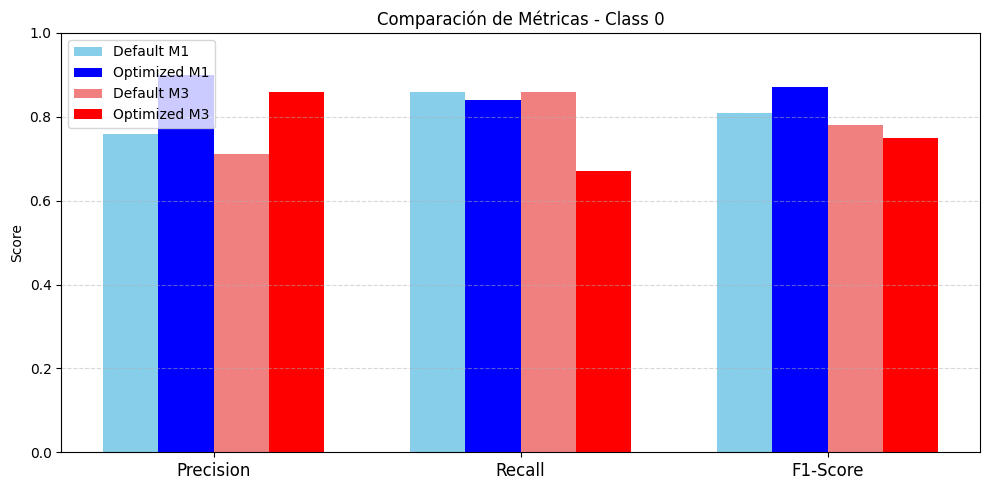

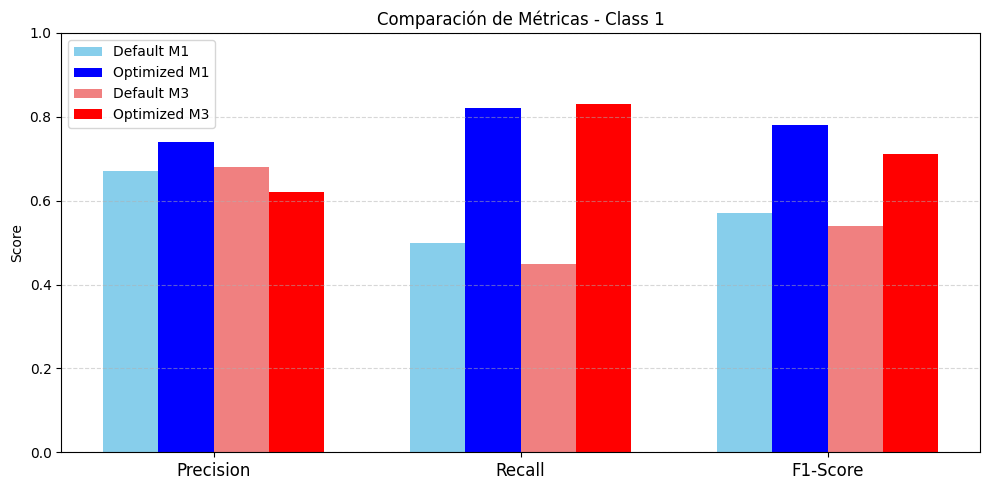

In [21]:
# Métricas por clase 
labels = ['Class 0', 'Class 1']

# Valores: [precision, recall, f1-score]
default_m1 = [[0.76, 0.86, 0.81], [0.67, 0.50, 0.57]]
optimized_m1 = [[0.90, 0.84, 0.87], [0.74, 0.82, 0.78]]
default_m3 = [[0.71, 0.86, 0.78], [0.68, 0.45, 0.54]]
optimized_m3 = [[0.86, 0.67, 0.75], [0.62, 0.83, 0.71]]

# Configuración
metrics = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.18

# Gráfica por clase
for i, cls in enumerate(labels):
    plt.figure(figsize=(10, 5))
    
    plt.bar(x - 1.5*width, default_m1[i], width, label='Default M1', color='skyblue')
    plt.bar(x - 0.5*width, optimized_m1[i], width, label='Optimized M1', color='blue')
    plt.bar(x + 0.5*width, default_m3[i], width, label='Default M3', color='lightcoral')
    plt.bar(x + 1.5*width, optimized_m3[i], width, label='Optimized M3', color='red')

    plt.xticks(x, metrics, fontsize=12)
    plt.ylabel('Score')
    plt.ylim(0, 1.0)
    plt.title(f'Comparación de Métricas - {cls}')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

In [22]:
#Guardamos el mejor modelo
with open('../models/06-boosting-grid-model-1', 'wb') as f:
    pickle.dump(grid_bm_1, f)

> ## Conclusiones:
>
> - Optimizando hiperparámetros de `XGBClassifier` con `GridSearchCV` hemos mejorado considerablemente las métricas de los modelos por defecto.
> - Llegamos a la conclusion final que el mejor modelo es el `grid_bm_1` (eliminando los datos invalidos y optimizando el modelo por defecto de `XGBClassifier` con `GridSearchCV`):
>
>  1. Tiene mejores métricas en el conjunto de test, tanto globales como por clase (excepto en recall)
>  2. El recall de la clase 1 (0.82) es levemente peor pero lo compensa con el resto de métricas que son significativamente mejores
>  3. Es más robusto y no tiene prácticamente overfitting